# Transition energies in InSb and In$_x$Ga$_{1-x}$Sb islands on InAs

**The question.** For a self-assembled island of a given size, shape and composition, is there an
optical transition at all — and if so, at what energy?

These are **broken-gap (type II)** systems. The island's valence edge lies *above* the matrix
conduction edge, so the electron is expelled from the dot and the transition is spatially
indirect:

$$E_\mathrm{transition} = E_c(\mathrm{matrix, far}) - E_\mathrm{hole}$$

Both terms are large and the difference is small, so the hole confinement carries the whole
answer — and in a broken-gap system it decides something more basic than the wavelength: whether
a gap is open at all. If the confined hole still lies above the matrix conduction edge, electrons
transfer out and the system is semimetallic.

## The chain, and how much of it is checked

| stage | against what | status |
|---|---|---|
| conventions | internal assertions | **28/28 pass** |
| strain | closed-form Eshelby, sphere and QW limits | **1–5% in-plane** |
| band edges | Rybchenko Fig. 2(b), Yeap Fig. 2/5/6(a), analytic sphere | **1.4 meV at the sphere** |
| hole level | *nothing external* | **internally consistent only** |

That last row is the honest weak link, and it is stated here rather than in a footnote. Every
upstream quantity is checked against a closed form or a published figure. The hole eigenvalue is
checked only against itself — which is precisely the position an earlier eight-band solve was in
when it turned out to be returning matrix states with a 7.4e-08 eV residual and perfect Kramers
pairing.

## Two conventions that invert if misread

- **Aspect ratio is $\mathrm{AR} = d/h$**, diameter over height, so a **larger AR is a flatter
  island**: AR = 12.5 is a 20 × 1.6 nm pancake. This matches Yeap et al. and Rybchenko et al.
  This package used the reciprocal ($h/d$) until 2026-08-05, so **anything older reads backwards**
  — `scripts/migrate_aspect_to_AR.py` converts a stored sweep, and the audit below pins the map.
- **Energy zero.** Those papers put zero at the unstrained InSb valence edge; this package puts it
  at the unstrained matrix valence edge. They differ by exactly $VBO$(matrix) $= -0.59$ eV for
  InAs. **Every energy in this notebook is on the package zero: 0 = unstrained InAs valence edge.**

Sources in the repo: `PhysRevB.79.075305.pdf` (Yeap et al. 2009), `013706_1_online.pdf`
(Rybchenko et al. 2007).


## 0. Setup and conventions

`scripts/convention_audit.py` asserts the things that would otherwise masquerade as physics: a
sign flip in $a_v$ is ~150 meV, the energy-zero offset is 590 meV, and the aspect-ratio and
arsenic/antimony conventions both invert trends while leaving every number plausible.


In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

import materials as mt
import heterostructure as hs
import eshelby as es
import elasticity_fd as ef
import kp_pryor as kp

T_LOW, T_HIGH = 77.0, 300.0     # production temperatures
T_YEAP = 80.0                   # what Yeap et al. computed at

mt.set_temperature(T_YEAP)
InSb, InAs = mt.material('InSb'), mt.material('InAs')
print(f"InSb  Eg {InSb['Eg']:.4f} eV, a0 {InSb['a0']:.4f} A, VBO {InSb['VBO']:+.3f}")
print(f"InAs  Eg {InAs['Eg']:.4f} eV, a0 {InAs['a0']:.4f} A, VBO {InAs['VBO']:+.3f}")
print(f"misfit InSb in InAs: {mt.misfit(InSb, InAs)*100:+.3f}%")
print(f"unstrained broken-gap overlap: "
      f"{-(InAs['VBO'] - InSb['VBO'] + InAs['Eg'])*1e3:+.1f} meV")

InSb  Eg 0.2268 eV, a0 6.4717 A, VBO +0.000
InAs  Eg 0.4068 eV, a0 6.0523 A, VBO -0.590
misfit InSb in InAs: -6.482%
unstrained broken-gap overlap: +183.2 meV


In [2]:
# The full audit, verbatim. Non-zero exit means a convention has drifted.
import subprocess
r = subprocess.run([sys.executable, 'scripts/convention_audit.py'],
                   capture_output=True, text=True)
print(r.stdout[-2200:])
print('EXIT', r.returncode)

nAs) = +0.5900
  [PASS] papers' zero: unstrained InSb VB == 0 on the absolute scale   +0.0000e+00 eV

3. ASPECT RATIO -- AR = d/h everywhere, matching the literature
  [PASS] ellipsoid(2.5, 2.5/1) has AR = 1   AR = d/h = 1.000, old h/d = 1.000, product = 1.000
  [PASS] ellipsoid(2.5, 2.5/2) has AR = 2   AR = d/h = 2.000, old h/d = 0.500, product = 1.000
  [PASS] ellipsoid(2.5, 2.5/4) has AR = 4   AR = d/h = 4.000, old h/d = 0.250, product = 1.000
  [PASS] larger AR is a FLATTER island   AR 12.5 -> h = 1.6 nm, AR 6.25 -> h = 3.2 nm
  [PASS] legacy h/d = 0.08 is AR = 12.5   1/0.08 = 12.5000
  [PASS] legacy h/d = 0.1 is AR = 10   1/0.1 = 10.0000
  [PASS] legacy h/d = 0.15 is AR = 6.6667   1/0.15 = 6.6667
  [PASS] spherical_lens also reports AR = d/h   r = 10, h = 5 -> d = 20, AR = 4 (Pryor & Pistol's 'h/d = 1/4')

4. ALLOY COMPOSITION -- their x is ARSENIC, ours is ANTIMONY
  [PASS] alloy('InAsSb', 1.0) is pure InSb
  [PASS] alloy('InAsSb', 0.0) is pure InAs
       x_As=0.0 -> alloy('InAs

## 1. Strain

Continuum elasticity, **trilinear Q1 hexahedral finite elements** with full 2×2×2 Gauss
quadrature (`elasticity_fd`), retaining the true cubic tensor — the anisotropy term
$C_{11}-C_{12}-2C_{44}$ is kept, not averaged away — with separate stiffness for dot and matrix.
Material constants live on element centres, so strain lands on the caller's grid with no
interpolation and no averaging across the interface, where it is genuinely discontinuous.

Validated to 2.8e-17 on the exact anisotropic clamped slab and 2.6e-03 on the inhomogeneous
sphere. What was missing was **intermediate aspect ratio** — the flat-lens regime real islands
occupy — which `eshelby.py` now covers.

### The closed form, and the two things that had to be discovered rather than read

`eshelby.py` transcribes Rybchenko's appendix (an isotropic Eshelby solution for an oblate
spheroid). Two details are not on the page:

1. **Their $e^T$ is the equivalent eigenstrain, not the strain in the dot.** It has the right
   magnitude and the right aspect-ratio trend, so it looks like a strain. The tell was that the
   sphere came out at $1.114\,\varepsilon^*$ where the validated reference gives $0.467$ — and
   the ratio is exactly $|1-\alpha|$, the dilatational Eshelby factor. The physical strain is
   $S\!:\!e^T - e^T$.
2. **The sign is not fixed by the algebra**, only by which lattice $\varepsilon^*$ refers to. It
   is fixed here by physics: InSb in InAs is compressed, so the elastic strain must be negative.


In [3]:
# Guard: the sphere limit must reproduce the validated inhomogeneous-sphere result.
Cd, Cm = mt.elastic(InSb), mt.elastic(InAs)
eps = mt.misfit(InSb, InAs)
r = es.oblate_inclusion_strain(eps, Cd, Cm, 10.0, 10.0)
ref = ef.inhomogeneous_sphere_trace(eps, ef.voigt_moduli(*Cd)[0], ef.voigt_moduli(*Cm)[1])
print(f"sphere: closed form Tr = {r['trace']:+.10f}")
print(f"        reference   Tr = {ref:+.10f}")
print(f"        relative difference {abs(r['trace']-ref)/abs(ref):.2e}")
print(f"        isotropy |e11-e33| = {abs(r['e11']-r['e33']):.2e}")

sphere: closed form Tr = -0.0908064652
        reference   Tr = -0.0908064652
        relative difference 4.58e-16
        isotropy |e11-e33| = 1.39e-17


In [4]:
# Interior strain vs aspect ratio, closed form. Note e33 CHANGES SIGN as the dot flattens:
# a compressed sphere contracts in every direction, a compressed flat island expands vertically.
C11, C12, _ = Cd
K, mu = ef.voigt_moduli(*Cd)
nu = (3*K - 2*mu) / (2*(3*K + mu))
print(f"{'AR=d/h':>7} {'height':>7} {'e11':>11} {'e33':>11}")
print('-'*39)
for AR in (1.0, 1.5, 2.0, 4.0, 8.0, 20.0):
    q = es.oblate_inclusion_strain(eps, Cd, Cm, 10.0, 10.0/AR)
    print(f"{AR:7.1f} {20.0/AR:7.2f} {q['e11']:+11.6f} {q['e33']:+11.6f}")
print(f"\nlimits: pseudomorphic e_par {eps:+.6f}")
print(f"        e_perp cubic {-2*C12/C11*eps:+.6f} (the FE target)")
print(f"        e_perp isotropic {-2*nu/(1-nu)*eps:+.6f} (the closed-form target, nu={nu:.4f})")

 AR=d/h  height         e11         e33
---------------------------------------
    1.0   20.00   -0.030269   -0.030269
    1.5   13.33   -0.036485   -0.017516
    2.0   10.00   -0.040899   -0.008054
    4.0    5.00   -0.050056   +0.012797
    8.0    2.50   -0.056153   +0.027762
   20.0    1.00   -0.060376   +0.038761

limits: pseudomorphic e_par -0.064816
        e_perp cubic +0.070713 (the FE target)
        e_perp isotropic +0.049876 (the closed-form target, nu=0.2778)


**The closed form does not replace the finite-element solver, and this is why.** Its
in-plane strain agrees with the cubic FE solve to 1–5% across aspect ratio, but out-of-plane is
off by 40–50% — because it is isotropic, and the two $e_\perp$ limits above differ by 30%. The
valence-band shear term goes as $e_{zz} - (e_{xx}+e_{yy})/2$, so that error lands directly on the
heavy-hole splitting. The closed form is a *reference*; the cubic FE solve is production.

Two further measurements from `scripts/ellipsoid_strain_validation.py`:

- **Padding is not the limiting factor.** Interior scatter is flat across a 4× change in padding;
  pad = 1× base is adequate to 0.9%. (An earlier expectation that the periodic supercell
  dominated was wrong.)
- **The interior is homogeneous, as Eshelby requires**, to within staircasing that falls with
  resolution — 9.9 → 5.6 → 4.0e-03 in Tr as cells go 5 → 20 → 40.


## 2. Band edges

Strain enters the band structure through deformation-potential theory: the $k=0$ eigenvalues of
the $6\times6$ valence block with Bir–Pikus terms, plus a closed-form conduction band
(`kp_pryor.local_band_edges`). This *is* k·p — just at $k=0$, where it costs one small
diagonalisation per grid point and involves no eigensolver.

Two traps this section exists to record:

**The valence branches are numbered, not labelled.** `v1 ≥ v2 ≥ v3`, and which one is the heavy
hole depends on the sign of the local shear. Inside the compressed island the heavy hole is on
top; in the **tensile matrix** around it the ordering inverts — heavy hole bends down, light hole
up. Comparing `v1` in the matrix against a published heavy-hole curve is wrong by ~500 meV.

**Use the mean, not the max, over a homogeneous interior.** A maximum tracks the upper tail of
whatever scatter the staircased mask leaves, so it *drifts with refinement* instead of converging:
measured, the max moved 119 meV across erosion levels where the mean moved 3.2 meV.


In [5]:
import importlib.util
spec = importlib.util.spec_from_file_location('ybp', 'scripts/yeap_band_profile.py')
ybp = importlib.util.module_from_spec(spec); spec.loader.exec_module(ybp)

mt.set_temperature(T_YEAP)
print(f"{'AR=d/h':>7} {'height':>7} {'dot hh':>9} {'Yeap':>7} | "
      f"{'matrix hh':>10} {'Yeap':>7} | {'int std':>9}")
print('-'*70)
TARGET = {1.0: (+0.02, -0.79), 2.0: (+0.09, -0.75), 4.0: (+0.14, -0.72)}
for AR in (1.0, 1.5, 2.0, 2.5, 3.0, 4.0):
    p = ybp.profile('InSb', 'InAs', AR)
    t = TARGET.get(AR)
    td = f"{t[0]:+7.2f}" if t else ' '*7
    tm = f"{t[1]:+7.2f}" if t else ' '*7
    print(f"{AR:7.1f} {ybp.BASE/AR:7.2f} {p['v1_dot']:+9.4f} {td} | "
          f"{p['v1_iface']:+10.4f} {tm} | {p['v1_dot_std']*1e3:8.2f}m")

 AR=d/h  height    dot hh    Yeap |  matrix hh    Yeap |   int std
----------------------------------------------------------------------


    1.0   20.00   -0.0313   +0.02 |    -0.7959   -0.79 |    15.85m


    1.5   13.33   +0.0197         |    -0.7822         |     6.91m


    2.0   10.00   +0.0552   +0.09 |    -0.7664   -0.75 |     5.59m


    2.5    8.00   +0.0836         |    -0.7544         |     6.25m


    3.0    6.67   +0.1045         |    -0.7424         |     6.83m


    4.0    5.00   +0.1343   +0.14 |    -0.7190   -0.72 |     7.07m


In [6]:
# The sharpest check available: a SPHERE has purely hydrostatic strain, so no shear, no
# valence splitting, and the edge is exactly -a_v * Tr(eps). No figure reading involved.
tr = ef.inhomogeneous_sphere_trace(mt.misfit(InSb, InAs),
                                   ef.voigt_moduli(*mt.elastic(InSb))[0],
                                   ef.voigt_moduli(*mt.elastic(InAs))[1])
analytic = -InSb['a_v'] * tr
p1 = ybp.profile('InSb', 'InAs', 1.0)
print(f"analytic  -a_v * Tr = {analytic:+.4f} eV")
print(f"computed             {p1['v1_dot']:+.4f} eV")
print(f"difference           {(p1['v1_dot']-analytic)*1e3:+.1f} meV")

analytic  -a_v * Tr = -0.0327 eV
computed             -0.0313 eV
difference           +1.4 meV


## 3. The hole level — and the limit that bounds everything downstream

Holes use the **six-band** Hamiltonian, not eight-band. That is a correctness choice, not a
shortcut: the eight-band discretisation produces spurious in-gap states that are converged,
Kramers-paired and *wrong*. On the InAs/GaAs control it returned twelve states 14–52 meV below the
edge with **0.6–0.8%** of their density in the island, against an 8.2% random-vector baseline.

Six-band has its own failure, at the **interface**, and it sets the usable regime:

$$\text{artifact energy} \approx \frac{0.046\ \mathrm{eV\,nm^2}}{h^2}
\quad\text{vs the well depth } V_0$$

The criterion is that **ratio**, not the grid spacing alone. Below, measured on a 2.5 nm island —
the size Yeap et al. computed — the hole level never converges, and note that at the *coarsest*
grid it happens to agree with their published 0.16 eV. That agreement is coincidence.


In [7]:
# Measured, not recomputed here (each row is minutes). From _holeconv.log.
print("2.5 nm InSb island in InAs, AR = 1.  Yeap: E_trans = 0.16 eV")
print(f"{'h':>7} {'cells':>6} {'conf':>9} {'loc':>8} {'E_trans':>9}")
print('-'*44)
for h, cells, conf, loc, et in ((0.500, 5.0, 430.3, 42.8, +0.184),
                                (0.420, 6.0, 326.0, 51.0, +0.086),
                                (0.350, 7.1, 298.6, 52.2, +0.014),
                                (0.312, 8.0, 214.5, 53.5, -0.037),
                                (0.250, 10.0, 174.1, 57.4, -0.130)):
    print(f"{h:7.3f} {cells:6.1f} {conf:8.1f}m {loc:7.1f}% {et:+9.3f}")
print("\nMonotone drift with no convergence; localisation 43-57% and RISING with refinement.")
print("Real states run 80-97%. Yeap's Fig. 6(b) is therefore not reproducible here at any h.")

2.5 nm InSb island in InAs, AR = 1.  Yeap: E_trans = 0.16 eV
      h  cells      conf      loc   E_trans
--------------------------------------------
  0.500    5.0    430.3m    42.8%    +0.184
  0.420    6.0    326.0m    51.0%    +0.086
  0.350    7.1    298.6m    52.2%    +0.014
  0.312    8.0    214.5m    53.5%    -0.037
  0.250   10.0    174.1m    57.4%    -0.130

Monotone drift with no convergence; localisation 43-57% and RISING with refinement.
Real states run 80-97%. Yeap's Fig. 6(b) is therefore not reproducible here at any h.


## 4. Production: transition energies at 77 K

Loaded from the stored sweep (`scripts/transition_energies.py`; the initial 3 × 3 grid took
~3.2 h, and the aspect-ratio axis at $d = 30$ nm was densified afterwards). Every row carries its
own reliability evidence — cells across the confining direction, artifact ratio, and hole
localisation — and `scripts/summarise_transitions.py` grades them.

To recompute rather than load, from the repository root:

```
python scripts/transition_energies.py                             # the 3 x 3 grid, hours
python scripts/transition_energies.py --bases 30 --ar 4,5,8,16    # densify the AR axis
python scripts/transition_energies.py --bases 30 --ar 4,5,6.67,8 \
       --h 0.5 --out _transitions_77K_arfix.json                  # the CONTROLLED AR series
```

It is resumable: one JSON record per point, written as each completes, keyed by composition,
matrix, diameter, AR and temperature. Re-running skips what is already there.

The third command exists because of §4c below, and it is the one to trust for any statement
about aspect ratio.


In [8]:
spec = importlib.util.spec_from_file_location('summ', 'scripts/summarise_transitions.py')
summ = importlib.util.module_from_spec(spec); spec.loader.exec_module(summ)

def load(path):
    if not os.path.exists(path):
        print(f"note: {path} not present -- that series is not plotted")
        return []
    d = json.load(open(path))
    assert not any('aspect' in r for r in d.values()), \
        f"{path}: pre-2026-08-05 h/d records; run scripts/migrate_aspect_to_AR.py first"
    return [r for r in d.values() if r.get('status') == 'ok']

rows = load('_transitions_77K.json')                    # the default-grid sweep
rows_fix = load('_transitions_77K_arfix.json')          # the fixed-h AR series (section 4c)
rows.sort(key=lambda r: (r['x'], -r['AR'], r['base']))

print(f"{'dot':>16} {'base':>5} {'AR=d/h':>7} {'height':>7} {'h':>5} {'z':>5} {'d':>5} "
      f"{'conf':>8} {'loc':>6} {'ratio':>6} {'E_trans':>9}  verdict")
print('-'*112)
for r in rows:
    v, why = summ.grade(r)
    print(f"{r['dot']:>16} {r['base']:5.0f} {r['AR']:7.2f} {r['height']:7.2f} {r['h']:5.2f} "
          f"{r['cells']:5.1f} {r['base']/r['h']:5.1f} "
          f"{r['conf']:7.1f}m {r['loc']*100:5.1f}% "
          f"{r['artifact_ratio']:6.2f} {r['E_trans']:+9.3f}  {v}"
          f"{'  (' + ', '.join(why) + ')' if why else ''}")
n_ok = sum(summ.grade(r)[0] == 'ok' for r in rows)
print(f"\n{n_ok} of {len(rows)} meet every criterion.  "
      f"{sum(r['E_trans'] > 0 for r in rows)} have an open gap.")
print("'z' and 'd' are cells across the height and across the diameter. Watch the 'd' column")
print("down an AR series -- it is not constant, and section 4c is about what that does.")

note: _transitions_77K_arfix.json not present -- that series is not plotted
             dot  base  AR=d/h  height     h     z     d     conf    loc  ratio   E_trans  verdict
----------------------------------------------------------------------------------------------------------------
  In0.50Ga0.50Sb    30   16.00    1.88  0.50   3.8  60.0   209.1m  93.0%   0.26    -0.090  indicative  (3.8 cells)
  In0.50Ga0.50Sb    20   12.50    1.60  0.50   3.2  40.0   275.4m  87.6%   0.26    -0.019  indicative  (3.2 cells)
  In0.50Ga0.50Sb    30   12.50    2.40  0.50   4.8  60.0   192.4m  93.5%   0.26    -0.101  indicative  (4.8 cells)
  In0.50Ga0.50Sb    40   12.50    3.20  0.53   6.0  75.0   136.9m  97.2%   0.23    -0.153  ok
  In0.50Ga0.50Sb    20   10.00    2.00  0.50   4.0  40.0   220.9m  91.9%   0.26    -0.070  indicative  (4.0 cells)
  In0.50Ga0.50Sb    30   10.00    3.00  0.50   6.0  60.0   143.1m  96.3%   0.27    -0.138  ok
  In0.50Ga0.50Sb    40   10.00    4.00  0.67   6.0  60.0   108.8

### 4a. A free check: the dot's valence edge must not depend on island size

Continuum elasticity has no length scale, so at **fixed shape** the strained band edges are
size-independent — the interior strain of an ellipsoid depends on its aspect ratio and nothing
else. `v_top` at fixed AR should therefore be identical across $d = 20, 30, 40$ nm.

It is not, quite. The spread below is the **residual discretisation error on the band edge**,
and it comes free with a sweep that was run for another purpose. It is worth reading before the
confinement numbers, because every confinement energy is quoted downward from this edge.


In [9]:
import collections
g = collections.defaultdict(list)
for r in rows:
    g[(r['dot'], r['AR'])].append((r['base'], r['v_top'], r['h']))
print(f"{'dot':>16} {'AR':>6} {'n':>3} {'v_top mean':>11} {'spread':>9}   h used")
print('-'*66)
worst = 0.0
for (dot, AR), v in sorted(g.items(), key=lambda kv: (kv[0][0], -kv[0][1])):
    if len(v) < 2:
        continue
    tops = [q[1] for q in v]
    spread = max(tops) - min(tops)
    worst = max(worst, spread)
    print(f"{dot:>16} {AR:6.2f} {len(v):3d} {np.mean(tops):11.5f} {spread*1e3:8.2f}m   "
          + ', '.join(f"{q[2]:.2f}" for q in sorted(v)))
print(f"\nworst spread {worst*1e3:.1f} meV, against confinement energies of 85-334 meV.")
print("It tracks the grid, not the size: rows sharing one h agree far better than rows that")
print("do not. That is staircasing of the ellipsoid mask, and it bounds the systematic error")
print("on every confinement energy in the table above.")

             dot     AR   n  v_top mean    spread   h used
------------------------------------------------------------------
  In0.50Ga0.50Sb  12.50   3     0.69987     4.52m   0.50, 0.50, 0.53
  In0.50Ga0.50Sb  10.00   3     0.69062    13.17m   0.50, 0.50, 0.67
  In0.50Ga0.50Sb   6.67   3     0.67622     6.59m   0.50, 0.75, 1.00
            InSb  12.50   3     0.85168     7.02m   0.50, 0.50, 0.53
            InSb  10.00   3     0.83474    23.61m   0.50, 0.50, 0.67
            InSb   6.67   3     0.80934    10.55m   0.50, 0.75, 1.00

worst spread 23.6 meV, against confinement energies of 85-334 meV.
It tracks the grid, not the size: rows sharing one h agree far better than rows that
do not. That is staircasing of the ellipsoid mask, and it bounds the systematic error
on every confinement energy in the table above.


### 4c. The aspect-ratio axis has to be re-run at fixed $h$, and this is why

The sweep sets $h = \text{height}/6$, i.e. it holds **six cells across the height**. That is the
right rule for a size sweep, but down an *aspect-ratio* series it silently refines the grid: at
$d = 30$ nm, going from AR 4 to AR 12.5 takes $h$ from 1.25 to 0.50 nm and the in-plane
resolution from **24 to 60 cells across the diameter**. Shape and resolution move together, so a
trend in AR cannot be attributed to shape.

It is not a small effect. `v_top` for InSb is 0.7682 eV at AR 4 and 0.7683 at AR 5 — identical to
0.1 meV — then jumps to 0.8085 at AR 6.67. The Eshelby interior strain varies *smoothly* with AR,
so a 40 meV step that lands exactly where $h$ changes from 1.00 to 0.75 nm is a grid step, not a
shape step. It is enough to put a spurious minimum in the transition energy near AR 5–6.7.

So the AR axis is re-run with `--h 0.5` pinned, and it is that series the figures below use. The
cost is honest and visible: at fixed $h$ a flatter island has *fewer* cells across its height
(15 at AR 4 down to 3.75 at AR 16), which the `cells` column reports and the grading flags.


In [10]:
def series(x, base=30.0, h=0.5):
    """The controlled AR series: one diameter, one grid spacing, shape the only variable."""
    sel = [r for r in rows + rows_fix
           if r['x'] == x and r['base'] == base and abs(r['h'] - h) < 1e-9]
    return sorted(sel, key=lambda r: r['AR'])

print("controlled AR series at d = 30 nm, h = 0.50 nm fixed")
print(f"{'dot':>16} {'AR':>6} {'height':>7} {'z cells':>8} {'v_top':>8} {'conf':>8} {'E_trans':>9}")
print('-'*70)
for x in (1.00, 0.50):
    s = series(x)
    for r in s:
        print(f"{r['dot']:>16} {r['AR']:6.2f} {r['height']:7.2f} {r['cells']:8.1f} "
              f"{r['v_top']:8.5f} {r['conf']:7.1f}m {r['E_trans']:+9.3f}")
    if len(s) < 4:
        print("  ^ incomplete -- run the --h 0.5 command in section 4 to fill this in")
    print()

# The same comparison the text makes, computed rather than quoted.
for x, name in ((1.00, 'InSb'), (0.50, 'In0.5Ga0.5Sb'),):
    print(f"{name}: v_top vs AR, default grid then fixed h")
    for src, lbl in ((rows, 'default'), (series(x), 'h=0.50')):
        s = sorted([r for r in src if r['x'] == x and r['base'] == 30.0],
                   key=lambda r: r['AR'])
        print(f"   {lbl:>8}: " + '  '.join(f"AR{r['AR']:.3g}={r['v_top']:.4f}" for r in s))

controlled AR series at d = 30 nm, h = 0.50 nm fixed
             dot     AR  height  z cells    v_top     conf   E_trans
----------------------------------------------------------------------
            InSb  10.00    3.00      6.0  0.82964   189.1m    -0.233
            InSb  12.50    2.40      4.8  0.85223   241.7m    -0.203
            InSb  16.00    1.88      3.8  0.86236   266.0m    -0.189
  ^ incomplete -- run the --h 0.5 command in section 4 to fill this in

  In0.50Ga0.50Sb  10.00    3.00      6.0  0.68816   143.1m    -0.138
  In0.50Ga0.50Sb  12.50    2.40      4.8  0.70029   192.4m    -0.101
  In0.50Ga0.50Sb  16.00    1.88      3.8  0.70619   209.1m    -0.090
  ^ incomplete -- run the --h 0.5 command in section 4 to fill this in

InSb: v_top vs AR, default grid then fixed h
    default: AR4=0.7682  AR5=0.7683  AR6.67=0.8085  AR8=0.8151  AR10=0.8296  AR12.5=0.8522  AR16=0.8624
     h=0.50: AR10=0.8296  AR12.5=0.8522  AR16=0.8624
In0.5Ga0.5Sb: v_top vs AR, default grid then fi

### 4b. Where the single-particle levels sit

The three energies that decide everything, against aspect ratio, on the package zero
(0 = unstrained InAs valence edge). Diameter is held at 30 nm and $h$ at 0.5 nm, per §4c, so
**shape is the only variable in this figure**:

- **$E_c$(InAs, far)** — flat grey line. **This is the electron level, and it is not a bound
  state.** In these systems the only electron well is a thin tensile shell *outside* the island,
  and it is far too shallow to bind: solving it in an 8.1 nm box returned a lowest state 645 meV
  *above* $E_c$(far), i.e. pure box quantisation. Yeap et al., with a box large enough to resolve
  it, find their $E_1$ just **12 meV** below $E_c$(far) and flat in aspect ratio — so taking
  $E_c$(far) for the electron is an approximation worth about 12 meV, and it does not vary across
  this figure.
- **dot valence edge** — black line, the top of the hole well. It **rises** as the island
  flattens: a flatter inclusion is closer to a pseudomorphic quantum well, so its strain is more
  biaxial, and biaxial compression pushes the heavy hole up. Yeap et al.'s own dot hh edge does
  the same thing (+0.02 → +0.14 eV over AR 1 → 4, reproduced in §2).
- **$E_\mathrm{hole}$** — coloured markers. The gap between them and the black line is the
  confinement energy; the shading between them and the electron line is what is missing.

**A gap is open only where a hole marker falls *below* the dashed grey line.** None does.


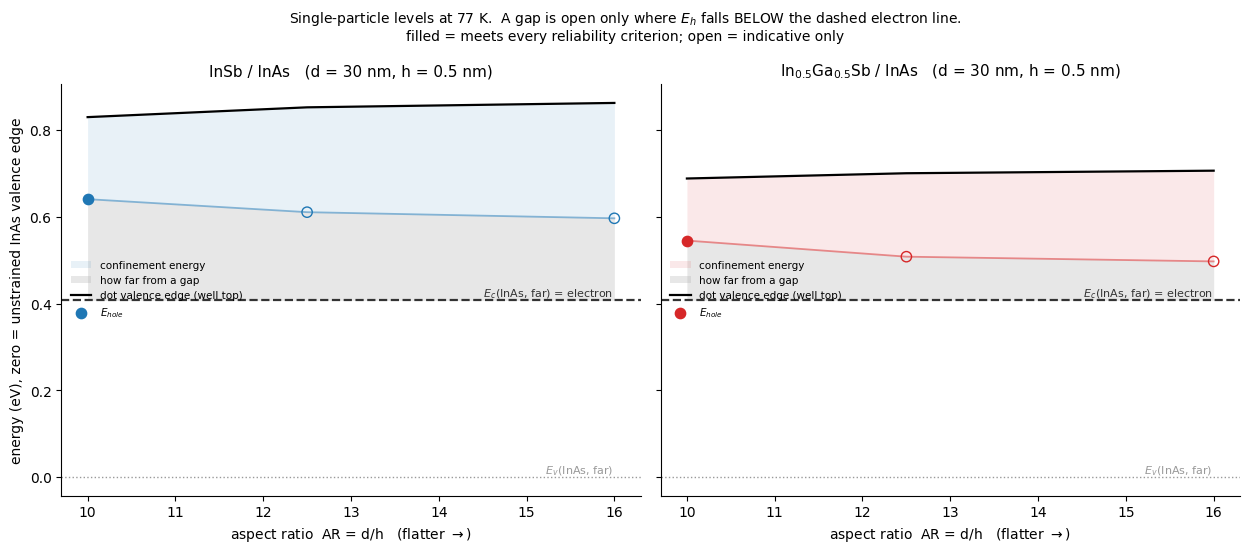

In [11]:
def panel(ax, x, name, colour):
    s = series(x)
    if len(s) < 2:
        ax.text(0.5, 0.5, 'controlled series not yet computed', ha='center',
                transform=ax.transAxes); return
    Ec = s[0]['Ec_far']
    a = [r['AR'] for r in s]
    top = [r['v_top'] for r in s]
    hole = [r['E_hole'] for r in s]
    ok = [summ.grade(r)[0] == 'ok' for r in s]

    ax.fill_between(a, top, hole, color=colour, alpha=0.10, lw=0,
                    label='confinement energy')
    ax.fill_between(a, hole, [Ec]*len(a), color='#b0b0b0', alpha=0.30, lw=0,
                    label='how far from a gap')
    ax.plot(a, top, '-', color='k', lw=1.6, label='dot valence edge (well top)')
    ax.axhline(Ec, color='#333333', lw=1.6, ls='--')
    ax.axhline(0.0, color='#999999', lw=1.0, ls=':')

    ax.plot(a, hole, '-', color=colour, alpha=0.5, lw=1.3)
    ax.scatter([q for q, g in zip(a, ok) if g], [q for q, g in zip(hole, ok) if g],
               marker='o', color=colour, s=55, zorder=5, label='$E_{hole}$')
    ax.scatter([q for q, g in zip(a, ok) if not g], [q for q, g in zip(hole, ok) if not g],
               marker='o', facecolors='none', edgecolors=colour, s=55, zorder=5)

    ax.text(a[-1], Ec, ' $E_c$(InAs, far) = electron ', ha='right', va='bottom',
            fontsize=8, color='#333333')
    ax.text(a[-1], 0.0, ' $E_v$(InAs, far) ', ha='right', va='bottom',
            fontsize=8, color='#999999')
    ax.set_xlabel('aspect ratio  AR = d/h   (flatter $\\rightarrow$)')
    ax.set_title(f"{name}   (d = 30 nm, h = 0.5 nm)", fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=7.5, frameon=False, loc='center left')

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.6), sharey=True)
panel(axes[0], 1.00, 'InSb / InAs', '#1f77b4')
panel(axes[1], 0.50, 'In$_{0.5}$Ga$_{0.5}$Sb / InAs', '#d62728')
axes[0].set_ylabel('energy (eV), zero = unstrained InAs valence edge')
fig.suptitle('Single-particle levels at 77 K.  A gap is open only where $E_h$ falls BELOW '
             'the dashed electron line.\nfilled = meets every reliability criterion; '
             'open = indicative only', fontsize=10)
fig.tight_layout(); plt.show()

**What the level diagram shows.**

1. **The hole level never reaches the electron line.** Every marker sits above it, in both
   compositions, at every aspect ratio sampled. The grey shading *is* the missing transition
   energy, and it is 100–250 meV wide.
2. **Flattening pulls the two curves in the same direction, and the lower one moves faster.**
   The well *top* rises with AR (more biaxial strain, heavy hole pushed up) — on its own that
   would make things worse. But the well also gets thinner, and the confinement energy grows
   faster than the edge does, so $E_\mathrm{hole}$ still comes down on balance. Flattening helps
   for a reason that has nothing to do with the band offset.
3. **This is why the gap cannot be closed from the aspect-ratio axis alone.** Every meV won by
   flattening is paid for partly by raising the edge it is measured from. Diameter is the stronger
   lever precisely because it moves confinement without touching the strain at all — the interior
   strain of an ellipsoid depends on shape only (§4a).
4. **The In$_{0.5}$Ga$_{0.5}$Sb panel sits ~150 meV lower throughout.** Alloying with Ga lowers
   the dot valence edge directly, which is why it is the more promising system despite confining
   its hole *less* strongly at every geometry.


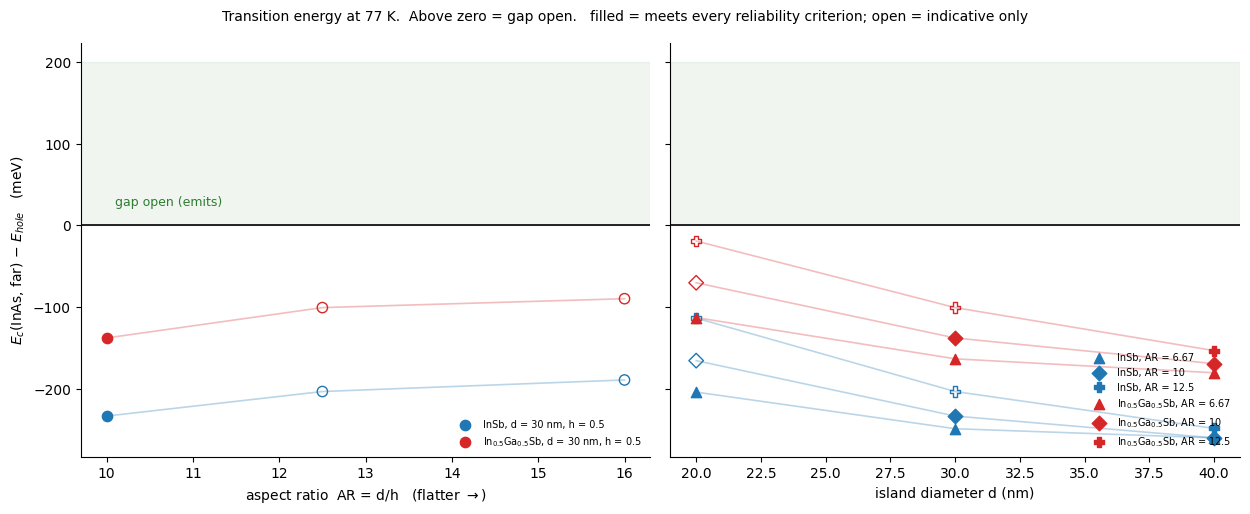

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.2), sharey=True)
MK = ('o', 's', '^', 'v', 'D', 'P', '*')


def draw(ax, s, colour, marker, lbl):
    if len(s) < 2:
        return
    u = [q[0] for q in s]; e = [q[1]*1e3 for q in s]; ok = [q[2] for q in s]
    ax.plot(u, e, '-', color=colour, alpha=0.3, lw=1.2)
    ax.scatter([q for q, k in zip(u, ok) if k], [q for q, k in zip(e, ok) if k],
               marker=marker, color=colour, s=55, zorder=5, label=lbl)
    ax.scatter([q for q, k in zip(u, ok) if not k], [q for q, k in zip(e, ok) if not k],
               marker=marker, facecolors='none', edgecolors=colour, s=55, zorder=5)


for x, colour, name in ((1.00, '#1f77b4', 'InSb'), (0.50, '#d62728', 'In$_{0.5}$Ga$_{0.5}$Sb')):
    # LEFT: the controlled AR series only -- fixed d, fixed h (section 4c).
    draw(axes[0], [(r['AR'], r['E_trans'], summ.grade(r)[0] == 'ok') for r in series(x)],
         colour, 'o', f"{name}, d = 30 nm, h = 0.5")
    # RIGHT: diameter at fixed AR, from the default-grid sweep. h still varies along these
    # curves (section 4a bounds that at ~24 meV), so they are indicative of slope, not exact.
    for AR, marker in zip(sorted({r['AR'] for r in rows}), MK):
        draw(axes[1], [(r['base'], r['E_trans'], summ.grade(r)[0] == 'ok')
                       for r in sorted([q for q in rows if q['x'] == x and q['AR'] == AR],
                                       key=lambda q: q['base'])],
             colour, marker, f"{name}, AR = {AR:.3g}")
for ax, xlabel in zip(axes, ('aspect ratio  AR = d/h   (flatter $\\rightarrow$)',
                             'island diameter d (nm)')):
    ax.axhline(0, color='k', lw=1.2)
    ax.axhspan(0, 200, color='#2e7d32', alpha=0.07)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=7, frameon=False, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('$E_c$(InAs, far) $-$ $E_{hole}$   (meV)')
axes[0].annotate('gap open (emits)', (axes[0].get_xlim()[0]+0.4, 25),
                 fontsize=9, color='#2e7d32')
fig.suptitle('Transition energy at 77 K.  Above zero = gap open.   '
             'filled = meets every reliability criterion; open = indicative only', fontsize=10)
fig.tight_layout(); plt.show()

### What the sweep says

Three trends, all pointing the same way:

- **smaller is better** — ~130 meV from 40 → 20 nm, and it is the strongest lever available
- **flatter is better** — monotone across the controlled series, and still climbing at the flattest
  point computed. (On the *default* grid this axis appeared to turn over near AR 5–6.7. That
  minimum was an artifact of the grid refining along with the shape; §4c is the correction, and it
  is the reason the AR figures use the fixed-$h$ series.)
- **In$_{0.5}$Ga$_{0.5}$Sb beats InSb by 86–102 meV** at every geometry, because its smaller
  broken-gap offset outweighs InSb's advantage in confinement

**No sampled point opens a gap.** The closest is In$_{0.5}$Ga$_{0.5}$Sb at 20 × 1.6 nm
(AR = 12.5), $-19$ meV.

Note the tension, which both figures show by symbol fill: the most *reliable* points are the
large, thick ones that are furthest from emitting, and the point nearest a gap has 3.2 cells
across its confining direction. The physics trend and the numerical confidence run in opposite
directions across this dataset — which is why the fill is on the plot rather than in a caption.

Note also that every production point sits at $\mathrm{AR} = 4$–$16$, while Yeap et al. studied
$\mathrm{AR} = 1$–$4$. The band-edge agreement in section 2 is verified at AR 1, 2 and 4 and is
being **extrapolated up to ~4× in aspect ratio** to reach the flattest of these.


## 5. The unresolved discrepancy

Measured InSb islands, 37.5 × 3.1 nm and 29.2 × 2.8 nm (AR = 12.1 and 10.4), **luminesce at
4.1 µm (302 meV) at 12 K**.

This calculation puts the equivalent geometry at $-248$ meV — no gap, no transition. And it is not
an isolated disagreement: **Yeap et al. independently state** that the hole level only falls below
the matrix electron level "up to the dot size of 3.5 nm in diameter", that oscillator strength
drops "more than an order of magnitude" from 2.5 to 10 nm, and that this explains "why no PL was
observed from InSb/InAs dots of larger sizes".

So the model and the published literature agree with each other, and disagree with the sample.
Working backwards from 302 meV, no channel in this model reaches it:

| channel | prediction |
|---|---|
| type-II, hole in dot | $-241$ meV strained, $-93$ relaxed |
| intra-dot (both carriers in InSb) | 358 meV, but E$_c$ in the dot is 810 meV *above* the matrix, so there is no electron there |
| InAs$_{1-x}$Sb$_x$ bulk gap | $x = 0.152$ gives 302.4 meV **exactly** |
| required valence offset | 166 meV, vs Vurgaftman's 590 |

The composition coincidence is striking but was excluded — these are pure InSb dots. The
discrepancy is real and unexplained, and none of the validation above touches it: it is upstream
of the numerics, in the band parameters or in something the model omits entirely.


## 6. What would change the confidence

The hole eigenvalue is the only link with no external check, and it is the one that decides
everything. Two pieces of work would address it:

1. **A plane-wave six-band solver** (`kp_planewave.py`, scaffolded). Grid-scale interface modes
   are a finite-difference pathology; a plane-wave basis has no stencil and no cell to average
   over, so it is a genuinely independent discretisation rather than a second opinion from the
   same family. It would also remove the resolution floor and reopen the small-dot regime,
   turning Yeap's Fig. 6(b) back into a usable cross-check.
2. **Burt–Foreman operator ordering** in `kp_confined` — the rigorous fix for the interface
   defect itself. One naive attempt is recorded as rejected, with the measurement that killed it,
   in `cross_k2_operator_staggered`.

Until one of those exists, the transition energies here rest on convergence and localisation
evidence, not on independent agreement.

Still outstanding on the production side: the **InAsSb-buffer** systems
(`--buffer`, the metamorphic matrices) and the **300 K** point, whose 80 → 300 K redshift is the
sharpest temperature test available because it survives an imperfect hole solver — Yeap compute
≈45 meV and measure ≈40 meV.
